# Libraries

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })
import numpy as np
import pandas as pd
import seaborn as sns
import scipy as sci
from sklearn.metrics import r2_score
import pickle

# Dataset upload and computing error model

### $x$ data

In [2]:
filename = r'/home/wmpjrufg/Documents/ic_andre_rimes/gen_dataset/z_dataset_1_wexp_menos_wfib2020ts.pkl'
with open(filename, 'rb') as f:
    dataset_x = pickle.load(f)

### $y$ data

In [3]:
data = pd.read_excel(r'/home/wmpjrufg/Documents/ic_andre_rimes/gen_dataset/data_models_rv2.xlsx', sheet_name='Modelos')
data.columns = data.columns.str.lower().str.replace(' ', '-')
data

,autor,output:-w_exp-(mm),fib-model-code-2020-(mm),wexp_menos_wfib2020,fib-model-code-2020--com-ts-variável-(mm),wexp_menos_wfib2020ts,norma-chinesa-(mm)
0,Viga S200-1.76-20 - Sokolov et al (2021),0.16,0.086159,0.073841,0.102130,0.057870,NaN
1,NaN,0.23,0.147127,0.082873,0.190783,0.039217,NaN
2,NaN,0.24,0.155568,0.084432,0.203058,0.036942,NaN
3,NaN,0.27,0.196838,0.073162,0.263069,0.006931,NaN
4,NaN,0.35,0.277502,0.072498,0.380363,-0.030363,NaN
...,...,...,...,...,...,...,...
336,NaN,0.19,0.217911,-0.027911,0.227492,-0.037492,NaN
337,NaN,0.22,0.247400,-0.027400,0.261534,-0.041534,NaN
338,Viga 23-6-11-2 - Clark (1956),0.17,0.150622,0.019378,0.150622,0.019378,NaN
339,Viga 23-6-11-3 - Clark (1956),0.19,0.108061,0.081939,0.108061,0.081939,NaN


### PySR model

In [4]:
filename = r'/home/wmpjrufg/Downloads/results_pysr_model_8020_fib2020ts-dataset1.pkl'
with open(filename, 'rb') as f:
    results_pysr_model_8020_dataset_1 = pickle.load(f)
    results_pysr_model_8020_dataset_1 = results_pysr_model_8020_dataset_1[1:]

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


### See best equation by R2 and Z-score parameters

In [5]:
df_models = {
                'r2 train': [],
                'r2 test': [],
                'rmse train': [],
                'rmse test': [],
                'score': [],
                'best equation': [],
            }
for idx, item in enumerate(results_pysr_model_8020_dataset_1):
    model = item["model"]
    df_models['r2 train'].append(model["train_r2"])
    df_models['r2 test'].append(model["test_r2"])
    df_models['rmse train'].append(model["train_rmse"])
    df_models['rmse test'].append(model["test_rmse"])
    df_models['score'].append(model["model_object"].get_best()['score'])
    df_models['best equation'].append(model["best_equation"])
df_models = pd.DataFrame(df_models)
df_models['gap rmse'] = abs(df_models['rmse train'] - df_models['rmse test'])
df_models['gap r2'] = abs(df_models['r2 train'] - df_models['r2 test'])
# df_models = df_models.sort_values(by='gap rmse')
# df_models = df_models.sort_values(by='gap r2')
df_models = df_models.sort_values(by='r2 train', ascending=False)
df_models.head()

,r2 train,r2 test,rmse train,rmse test,score,best equation,gap rmse,gap r2
22,0.771510,0.673881,0.043880,0.045795,0.078324,0.032831933 * (sin(numero_de_barras_em_uma_cam...,0.001915,0.097628
34,0.765138,0.585342,0.043033,0.059614,0.100841,(((sin(largura_da_viga_b_mm / -0.00021681454) ...,0.016581,0.179795
62,0.763883,0.744719,0.043715,0.043629,0.049704,(sin(diametro_da_armadura_mm) + ((sin(numero_d...,0.000086,0.019164
12,0.728814,0.671445,0.046820,0.050488,0.099888,((eurocode_2 - ((beta_conforme_fields_e_bischo...,0.003668,0.057369
66,0.728422,0.744255,0.046087,0.047359,0.092153,(diametro_da_armadura_mm + ((sin(exp(1.907056 ...,0.001272,0.015833


In [6]:
best_index = df_models['r2 train'].idxmax()
best_index

22

In [7]:
equation = df_models.iloc[0]['best equation']
equation

'0.032831933 * (sin(numero_de_barras_em_uma_camada) + ((1.450178 * (sin(cube(1.61428 / largura_da_viga_b_mm)) + diametro_da_armadura_mm)) + (((clark_1956 - espacamento_entre_as_barras_mm) * momento_fletor_ms_knm) - eurocode_2)))'

In [8]:
def computing_equation(df, lista_colunas, lista_medias, lista_desvios):
    df_z = df.copy()
    for col, mi, sigma in zip(lista_colunas, lista_medias, lista_desvios):
        if sigma != 0:
            df_z[col] = (df[col] - mi) / sigma
        else:
            df_z[col] = 0.0

    # --- Variables used by the PySR equation (Z-scored) ---
    n_barras   = df_z["numero_de_barras_em_uma_camada"]
    b_viga     = df_z["largura_da_viga_b_mm"]
    diametro   = df_z["diametro_da_armadura_mm"]
    clark1956  = df_z["clark_1956"]
    espac      = df_z["espacamento_entre_as_barras_mm"]
    momento    = df_z["momento_fletor_ms_knm"]
    w_ec2      = df_z["eurocode_2"]

    # --- PySR best equation ---
    # '0.032831933 * (sin(numero_de_barras_em_uma_camada) + ((1.450178 * (sin(cube(1.61428 / largura_da_viga_b_mm)) + diametro_da_armadura_mm)) + (((clark_1956 - espacamento_entre_as_barras_mm) * momento_fletor_ms_knm) - eurocode_2)))'
    theta = (1.61428 / b_viga) ** 3
    alpha = np.sin(n_barras) + 1.450178 * (np.sin(theta) + diametro)
    omega = (clark1956 - espac) * momento - w_ec2

    return theta, alpha, omega, 0.032831933 * (alpha  + omega)

In [9]:
mycolumns = [
                'numero_de_barras_em_uma_camada',
                'largura_da_viga_b_mm',
                'diametro_da_armadura_mm',
                'clark_1956',
                'espacamento_entre_as_barras_mm',
                'momento_fletor_ms_knm',
                'eurocode_2'
            ]
avg = []
std = []
for j in mycolumns:
    avg.append(results_pysr_model_8020_dataset_1[best_index][j]['avg'])
    std.append(results_pysr_model_8020_dataset_1[best_index][j]['std_dev'])

### Build whole dataset to compare

In [10]:
w = dataset_x[1].copy()
w['output:-w_exp-(mm)'] = data['output:-w_exp-(mm)']
w['fib'] = data['fib-model-code-2020--com-ts-variável-(mm)']
w['theta'], w['alpha'], w['omega'], w['error'] = computing_equation(w, mycolumns , avg, std)
w['wnum'] = w['fib'] + w['error']
w['wnum/wexp'] = w['wnum'] / w['output:-w_exp-(mm)']

In [11]:
w.to_excel(r'/home/wmpjrufg/Documents/ic_andre_rimes/test_model_error/fib2020ts/statistics_pysr_dataset1ts_results.xlsx', index=False)

In [12]:
data = w.copy()
data.head()

,diametro_da_armadura_mm,resistencia_do_aco_fy_mpa,numero_de_barras_em_uma_camada,espacamento_entre_as_barras_mm,resistencia_a_tracao_do_concreto_mpa,cobrimento_mm,distancia_ao_centro_de_gravidade_da_armadura_mm,largura_da_viga_b_mm,altura_da_viga_h_mm,area_de_aco_tracionada_as_mm2,...,slip_de_yuan_et_al_2025,slip_de_biscaia_e_soares_2020,output:-w_exp-(mm),fib,theta,alpha,omega,error,wnum,wnum/wexp
0,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,...,0.109686,0.082007,0.16,0.102130,1589.433395,-0.140487,2.409846,0.074507,0.176637,1.103982
1,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,...,0.193326,0.156266,0.23,0.190783,1589.433395,-0.140487,1.242548,0.036183,0.226965,0.986806
2,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,...,0.205301,0.167096,0.24,0.203058,1589.433395,-0.140487,1.090801,0.031201,0.234258,0.976076
3,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,...,0.265222,0.221958,0.27,0.263069,1589.433395,-0.140487,0.383518,0.007979,0.271048,1.003881
4,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,...,0.388948,0.338382,0.35,0.380363,1589.433395,-0.140487,-0.833062,-0.031963,0.348400,0.995427


### Mean and standard deviation

In [13]:
data.describe()

,diametro_da_armadura_mm,resistencia_do_aco_fy_mpa,numero_de_barras_em_uma_camada,espacamento_entre_as_barras_mm,resistencia_a_tracao_do_concreto_mpa,cobrimento_mm,distancia_ao_centro_de_gravidade_da_armadura_mm,largura_da_viga_b_mm,altura_da_viga_h_mm,area_de_aco_tracionada_as_mm2,...,slip_de_yuan_et_al_2025,slip_de_biscaia_e_soares_2020,output:-w_exp-(mm),fib,theta,alpha,omega,error,wnum,wnum/wexp
count,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,...,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000,341.000000
mean,17.881056,468.002933,2.492669,63.850254,3.090431,32.846188,43.834604,202.572141,337.636950,680.651320,...,0.276129,0.240335,0.261672,0.266323,-61129.585779,-0.098080,-0.040996,-0.004566,0.261757,1.028020
std,6.258067,102.262652,1.364715,46.751976,0.501076,10.776445,12.213950,104.753565,111.788192,585.507137,...,0.129666,0.109379,0.115072,0.117894,227707.441792,1.643771,1.494618,0.078500,0.102065,0.174323
min,9.520000,276.000000,1.000000,12.000000,2.384602,12.800000,23.900000,100.000000,161.000000,78.500000,...,0.070935,0.051614,0.140000,0.052197,-906581.568726,-3.631618,-3.992244,-0.173610,0.090596,0.566222
25%,12.000000,392.000000,2.000000,40.000000,2.800000,25.000000,35.000000,150.000000,250.000000,315.000000,...,0.191853,0.168592,0.190000,0.178993,-33.439094,-1.295601,-0.786352,-0.049991,0.202480,0.911886
50%,16.000000,500.000000,2.000000,46.000000,2.920876,30.000000,40.500000,152.400000,348.000000,452.000000,...,0.255402,0.221958,0.230000,0.250469,-4.395739,-0.389615,0.023043,-0.001532,0.235472,1.014025
75%,20.000000,528.000000,3.000000,69.800000,3.269000,40.000000,49.100000,250.000000,381.000000,800.000000,...,0.338895,0.296132,0.300000,0.330521,1.419187,1.045363,0.908348,0.038703,0.288002,1.138402
max,35.800000,628.000000,9.000000,296.000000,5.308474,70.000000,94.500000,600.000000,604.000000,2826.000000,...,0.913442,0.676814,0.790000,0.701453,1589.433395,4.008362,6.476079,0.193845,0.707087,1.625750


### $R^2$

In [14]:
obs = data['output:-w_exp-(mm)']
pred = data['wnum']
r2_fib_model_2020 = r2_score(obs, pred)
r2_fib_model_2020

0.8515305402014628

# Charts

In [15]:
name = 'fib_model_2020t-com-ts-variável-pysr-model-dataset-1-8020'

### Predict versus Experimental

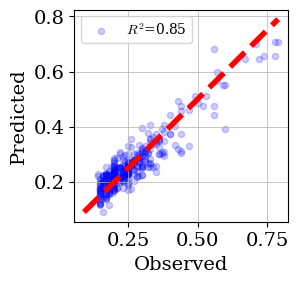

In [16]:
dpi = 600               # Change as you wish
b_cm = 7                       # Change as you wish
h_cm = 7                        # Change as you wish
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm
label_x = 'Observed'            # Change as you wish
label_y = 'Predicted'           # Change as you wish
size_label = 14                 # Change as you wish
color_label = 'black'            # or hexadecimal. Change as you wish
size_axis = 14                  # Change as you wish
color_axis = 'black'              # or hexadecimal. Change as you wish
size_line = 4           # Change as you wish
style_line = '--'       # Change as you wish
color_line = 'red'      # or hexadecimal. Change as you wish
labels_legend = [rf'$R^2$={r2_fib_model_2020:.2f}']   # Change as you wish
size_legend = 10                # Change as you wish
location_legend = 'upper left'  # Change as you wish - 'best' look up by the best fit
fig, ax = plt.subplots(figsize=(b_input, h_input))
lims = [
            min(data['output:-w_exp-(mm)'].min(), data['wnum'].min()),
            max(data['output:-w_exp-(mm)'].max(), data['wnum'].max())
        ]

# Config axis
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)

# Config grid
on_or_off = True
plt.grid(on_or_off, which='both', linestyle='-', linewidth=0.5)

# Plot data y = x and scatter
ax.plot(lims, lims, linewidth=size_line, linestyle=style_line, color=color_line,)
ax.scatter(data["output:-w_exp-(mm)"], data["wnum"], alpha=0.2, color='blue', s=20, label=labels_legend[0])
ax.legend(fontsize=size_legend, loc=location_legend)

# Save. Do you need save? Use the cell bellow:
fig.savefig(f'z_scatter-line_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()

### KDE numerical model - original model

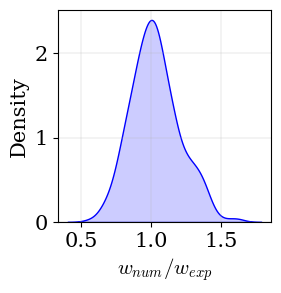

In [17]:
dpi = 600               

b_cm = 7            
h_cm = 7
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm

label_y = 'Density'
label_x = '$w_{num}/w_{exp}$'   
size_label = 15
color_label = 'black'
size_axis = 15
color_axis = 'black'           

labels_legend = ['fib Model 2020']   
size_legend = 9                
location_legend = 'upper right'  

fig, ax = plt.subplots(figsize=(b_input, h_input))
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)
on_or_off = True
plt.grid(on_or_off, which='both', linestyle='-', linewidth=0.2)
sns.kdeplot(data=data, x='wnum/wexp', fill=True, alpha=0.2, color='blue', ax=ax, label=labels_legend[0])
# ax.legend(fontsize=size_legend, loc=location_legend)
fig.savefig(f'z_kde_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()

# Goodness-of-fit

### Anderson-Darling test

Normal

In [18]:
# alpha = 5
# res = sci.stats.anderson(np.log(data['wnum/wexp']), dist="norm")
# stat = res.statistic
# crit = res.critical_values[res.significance_level == alpha][0]
# decision = "Accepted" if stat < crit else "Rejected"
# print(f"AD Statistic: {stat:.4f}")
# print(f"Critical Value at {alpha}% significance level: {crit:.4f}")
# print(f"Null Hypothesis: {decision}")

### Kolmogorov-Smirnov test

t-student

In [19]:
x = data['wnum/wexp'].values
df, loc, scale = sci.stats.t.fit(x)
print(f"\nFitted Student-t parameters:\nDegrees of freedom: {df:.4f}, Location: {loc:.4f}, Scale: {scale:.4f}")
ks_stat, ks_p = sci.stats.kstest(x, 't', args=(df, loc, scale))
print("\nKolmogorov-Smirnov Test for Student-t Distribution:")
print(f"Student-t KS statistic: {ks_stat:.4f}")
print(f"p-value: {ks_p:.4f}")


Fitted Student-t parameters:
Degrees of freedom: 36.1781, Location: 1.0263, Scale: 0.1692

Kolmogorov-Smirnov Test for Student-t Distribution:
Student-t KS statistic: 0.0517
p-value: 0.3101


Normal

In [20]:
x = data['wnum/wexp'].values
loc, scale = sci.stats.norm.fit(x)
print(f"\nFitted Normal parameters:\nLocation: {loc:.4f}, Scale: {scale:.4f}")
ks_stat, ks_p = sci.stats.kstest(x, 'norm', args=(loc, scale))
print("\nKolmogorov-Smirnov Test for Normal Distribution:")
print(f"Normal KS statistic: {ks_stat:.4f}")
print(f"p-value: {ks_p:.4f}")


Fitted Normal parameters:
Location: 1.0280, Scale: 0.1741

Kolmogorov-Smirnov Test for Normal Distribution:
Normal KS statistic: 0.0577
p-value: 0.1990


Log-normal

In [21]:
x = data['wnum/wexp'].values
shape, loc, scale = sci.stats.lognorm.fit(x)
print(f"\nFitted Lognormal parameters:\nShape: {shape:.4f}, Location: {loc:.4f}, Scale: {scale:.4f}")
ks_stat, ks_p = sci.stats.kstest(x, 'lognorm', args=(shape, loc, scale))
print("\nKolmogorov-Smirnov Test for Lognormal Distribution:")
print(f"Lognormal KS statistic: {ks_stat:.4f}")
print(f"p-value: {ks_p:.4f}")


Fitted Lognormal parameters:
Shape: 0.1312, Location: -0.2932, Scale: 1.3099

Kolmogorov-Smirnov Test for Lognormal Distribution:
Lognormal KS statistic: 0.0335
p-value: 0.8248


### Genetate statistics for Lognormal

In [22]:
mu = np.log(scale)
sigma = shape

mean = loc + np.exp(mu + 0.5*sigma**2)
var = (np.exp(sigma**2) - 1) * np.exp(2*mu + sigma**2)
std = np.sqrt(var)

print("\nLognormal Distribution Moments after fitting:")
print(f"Mean = {mean:.3f}")
print(f"Std  = {std:.3f}")


Lognormal Distribution Moments after fitting:
Mean = 1.028
Std  = 0.174


#### Generate synthetic data

In [23]:
sigma = np.sqrt(np.log(1 + (std / mean)**2))
mu = np.log(mean) - 0.5 * sigma**2

shape = sigma
loc = 0.0
scale = np.exp(mu)

print(f"shape = {shape:.4f}")
print(f"loc   = {loc:.4f}")
print(f"scale = {scale:.4f}")

n_samples = 20000
synthetic_data = sci.stats.lognorm.rvs(s=shape, loc=loc, scale=scale, size=n_samples)

shape = 0.1681
loc   = 0.0000
scale = 1.0136


In [24]:
# Double check the fit on the synthetic data
x = synthetic_data.copy()
shape, loc, scale = sci.stats.lognorm.fit(x)
print(f"\nFitted Lognormal parameters:\nShape: {shape:.4f}, Location: {loc:.4f}, Scale: {scale:.4f}")
ks_stat, ks_p = sci.stats.kstest(x, 'lognorm', args=(shape, loc, scale))
print("\nKolmogorov-Smirnov Test for Lognormal Distribution:")
print(f"Lognormal KS statistic: {ks_stat:.4f}")
print(f"p-value: {ks_p:.4f}")


Fitted Lognormal parameters:
Shape: 0.1774, Location: 0.0509, Scale: 0.9629

Kolmogorov-Smirnov Test for Lognormal Distribution:
Lognormal KS statistic: 0.0042
p-value: 0.8774


#### Synthetic data versus original data

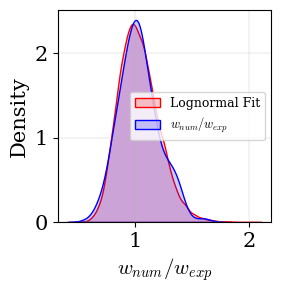

In [25]:
fig, ax = plt.subplots(figsize=(b_input, h_input))
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)
on_or_off = True
plt.grid(on_or_off, which='both', linestyle='-', linewidth=0.2)
sns.kdeplot(data=synthetic_data, fill=True, alpha=0.2, color='red', label='Lognormal Fit', ax=ax)
sns.kdeplot(data=list(data['wnum/wexp']), fill=True, alpha=0.2, color='blue', label='$w_{num}/w_{exp}$', ax=ax)
ax.legend(fontsize=size_legend, loc='center right')
fig.savefig(f'z_kde_{name}_gt_versus_lognormal.png', dpi=dpi, bbox_inches='tight')
plt.show()